# Brownian Bridge Path Construction


[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/QMCSoftware/QMCSoftware/blob/develop/demos/brownian_bridge.ipynb)

`BrownianMotion` supports multiple path construction methods via the `decomp_type` parameter, including `'PCA'` and `'Cholesky'`. This notebook introduces `'BrownianBridge'`, which samples time points by conditioning on the two nearest time values that have already been sampled. The default order follows the van der Corput sequence, with the first term replaced by the terminal time and the full sequence scaled by the provided `t_final`. This ensures that each QMC dimension is used in decreasing order of variance. A custom order can also be provided through `monitoring_times`. 

In [8]:
from qmcpy import *
import numpy as np
from matplotlib import pyplot
%matplotlib inline
pyplot.rc('font', size=14)
pyplot.rc('axes', titlesize=14)
pyplot.rc('axes', labelsize=14)
pyplot.rc('xtick', labelsize=14)
pyplot.rc('ytick', labelsize=14)
pyplot.rc('legend', fontsize=14)
pyplot.rc('figure', titlesize=14)

In [9]:
vdc = DigitalNetB2(1,randomize=False,order='Gray')(6)
vdc

array([[0.   ],
       [0.5  ],
       [0.75 ],
       [0.25 ],
       [0.375],
       [0.875]])

## Basic Usage


The `decomp_type` parameter is documented in the `BrownianMotion` constructor:

In [10]:
help(BrownianMotion.__init__)

Help on function __init__ in module qmcpy.true_measure.brownian_motion:

__init__(
    self,
    sampler,
    t_final=1,
    initial_value=0,
    drift=0,
    diffusion=1,
    decomp_type='PCA',
    lazy_decomp=True,
    monitoring_times=None,
    vdc_ordering=True
)
    Args:
        sampler (Union[AbstractDiscreteDistribution, AbstractTrueMeasure]): Either

            - a discrete distribution from which to transform samples, or
            - a true measure by which to compose a transform.
        t_final (float): End time.
        initial_value (float): Initial value $B_0$.
        drift (int): Drift $\gamma$.
        diffusion (int): Diffusion $\sigma^2$.
        decomp_type (str): Method for decomposition for covariance matrix. Options include

            - `'PCA'` for principal component analysis,
            - `'Cholesky'` for cholesky decomposition, or
            - `'BrownianBridge'` for brownian bridge construction.
        lazy_decomp (bool): If True, defer expensive matri

In [42]:
l4 = Lattice(4, seed=7)
bm = BrownianMotion(l4, decomp_type='BrownianBridge')
bm, l4(1)

(BrownianMotion (AbstractTrueMeasure)
     time_vec        [0.25 0.5  0.75 1.  ]
     drift           0
     mean            [0. 0. 0. 0.]
     covariance      [[0.25 0.25 0.25 0.25]
                      [0.25 0.5  0.5  0.5 ]
                      [0.25 0.5  0.75 0.75]
                      [0.25 0.5  0.75 1.  ]]
     decomp_type     BROWNIANBRIDGE,
 array([[0.04386058, 0.58727432, 0.3691824 , 0.65212985]]))

In [43]:
x4 = bm.gen_samples(4)
x4

array([[-0.23348439, -0.74350199, -1.34361627, -1.70754305],
       [-0.67511198, -0.62378384,  0.1400663 ,  0.1101646 ],
       [-0.32813769, -0.4810274 , -0.92845344, -0.54214131],
       [ 0.90822324,  0.90160358,  0.9679916 ,  0.81988997]])

## Brownian Bridge Construction

Given a Brownian motion $W$ with $W(0) = 0$, the conditional distribution of an interior value given its two surrounding anchor points is

$$W(s) \;\Big|\; W(\ell),\, W(r) \;\sim\; \mathcal{N}(\mu,\, \sigma^2)$$

with $\ell$ and $r$ as the nearest sampled neighbors below and above $s$. The conditional mean and variance are

$$\mu = W(\ell) + \frac{s - \ell}{r - \ell}\big(W(r) - W(\ell)\big), \qquad \sigma^2 = \frac{(s - \ell)(r - s)}{r - \ell}.$$

Manipulating the mean equation, the result is

$$W(s_j) = a_j\,W(\ell_j) + b_j\,W(r_j) + w_j\,Z_j, \qquad Z_j \sim \mathcal{N}(0,1),$$

with coefficients $a_j$ and $b_j$ depending on which neighbors are available, which creates four cases:

| case | $a_j$ | $b_j$ | $w_j$ |
|------|-------|-------|-------|
| first point, no neighbor | $0$ | $0$ | $\sqrt{s_j}$ |
| left neighbor only | $1$ | $0$ | $\sqrt{s_j - \ell_j}$ |
| right neighbor only | $0$ | $s_j / r_j$ | $\sqrt{s_j (r_j - s_j) / r_j}$ |
| both neighbors | $\dfrac{r_j - s_j}{r_j - \ell_j}$ | $\dfrac{s_j - \ell_j}{r_j - \ell_j}$ | $\sqrt{\dfrac{(s_j - \ell_j)(r_j - s_j)}{r_j - \ell_j}}$ |

(Owen, equations 6.10 and 6.11, Algorithm 6.1 [[1](#ref1)])

### Non-Power-of-2 Dimensions

The same four cases apply regardless of $d$. However, a `ParameterWarning` is raised whenever $d$ is not a power of 2 since the resulting time grid is no longer split into equally spaced intervals for a van der Corput sequence.

## Covariance Factorization

`'PCA'` and `'Cholesky'` each produce a matrix $A$ with $AA^\top = \Sigma$, where $\Sigma_{ij} = \min(t_i, t_j)$ is the Brownian motion covariance, and build a path as $W = AZ$ for $Z \sim \mathcal{N}(0, I)$. PCA uses the eigendecomposition $\Sigma = P\Lambda P^\top$ and takes $A = P\Lambda^{1/2}P^\top$. Cholesky decomposition identifies a lower triangular matrix $L$ with $LL^\top = \Sigma$, and takes $A = L$.

The bridge produces the same factorization without factoring $\Sigma$. For $d = 4$, using the gray-coded digital net order and sorting by increasing time,

$$W(\tfrac14) = \tfrac14 Z_1 + \tfrac14 Z_2 + \sqrt{\tfrac18}\, Z_4$$
$$W(\tfrac12) = \tfrac12 Z_1 + \tfrac12 Z_2$$
$$W(\tfrac34) = \tfrac34 Z_1 + \tfrac14 Z_2 + \sqrt{\tfrac18}\, Z_3$$
$$W(1) = Z_1$$

Where $A_{ij}$ is the coefficient of $Z_j$ in $W(t_i)$, a matrix $A$ is created that satisfies $AA^\top = \Sigma$ [[2](#ref2)].

In [13]:
d = 4
bm = BrownianMotion(Lattice(d, seed=7), decomp_type='BrownianBridge')

A = bm._bridge_transform(np.eye(d)).T

Sigma = np.minimum.outer(bm.time_vec, bm.time_vec)  

print("A:")
print(A.round(6))
print(f"\nmax |A A^T − Σ|  =  {np.max(np.abs(A @ A.T - Sigma)):.2e}")

A:
[[0.25     0.25     0.       0.353553]
 [0.5      0.5      0.       0.      ]
 [0.75     0.25     0.353553 0.      ]
 [1.       0.       0.       0.      ]]

max |A A^T − Σ|  =  0.00e+00


## Path Construction for Increasing $d$

BrownianBridge paths for $d \in \{1, 2, 3, 4, 5, 6, 7, 8, 128\}$. For powers of 2 ($d = 4$ and $d = 8$), paths at shared time points are identical, meaning that the $d = 8$ paths are essentially a refinement of the $d = 4$ paths. Going from $d = 4$ to $d = 8$ simply inserts new points in between existing points. For non-powers of 2 ($d = 5, 6, 7$), the bisection adds time points at non-midpoint locations.

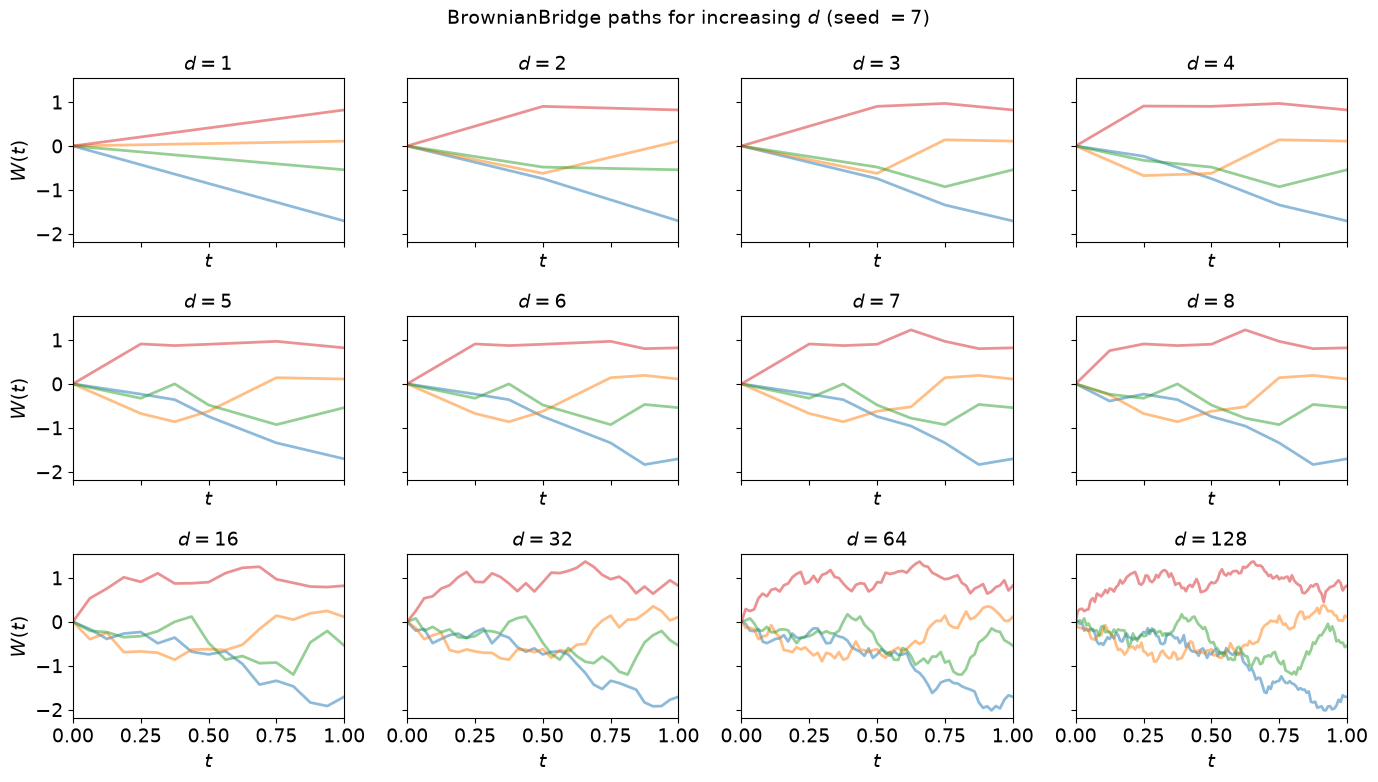

In [27]:
import warnings

dims = [1,2,3,4,5,6,7,8,16,32,64,128]
n = 4
t_final = 1.0
seed = 7

fig, axes = pyplot.subplots(3, 4, figsize=(14, 8), sharey=True, sharex=True)
axes_flat = axes.flatten()

for ax, d in zip(axes_flat, dims):
    with warnings.catch_warnings():
        warnings.simplefilter('ignore')
        bm = BrownianMotion(Lattice(d, seed=seed), t_final=t_final, decomp_type='BrownianBridge')
    paths = bm.gen_samples(n)
    paths_with_origin = np.concat([np.zeros((n,1)), paths], axis=-1)
    times = np.concat([[0], bm.time_vec])
    for path in paths_with_origin:
        ax.plot(times, path, "-", alpha=0.5, linewidth=2)
    ax.set_title(f'$d = {d}$')
    ax.set_xlabel('$t$')
    ax.set_xlim(0, t_final)

for ax in axes[:, 0]:
    ax.set_ylabel('$W(t)$')
pyplot.suptitle('BrownianBridge paths for increasing $d$ (seed $= 7$)')
pyplot.tight_layout()
pyplot.show()

## Comparing Decomposition Types

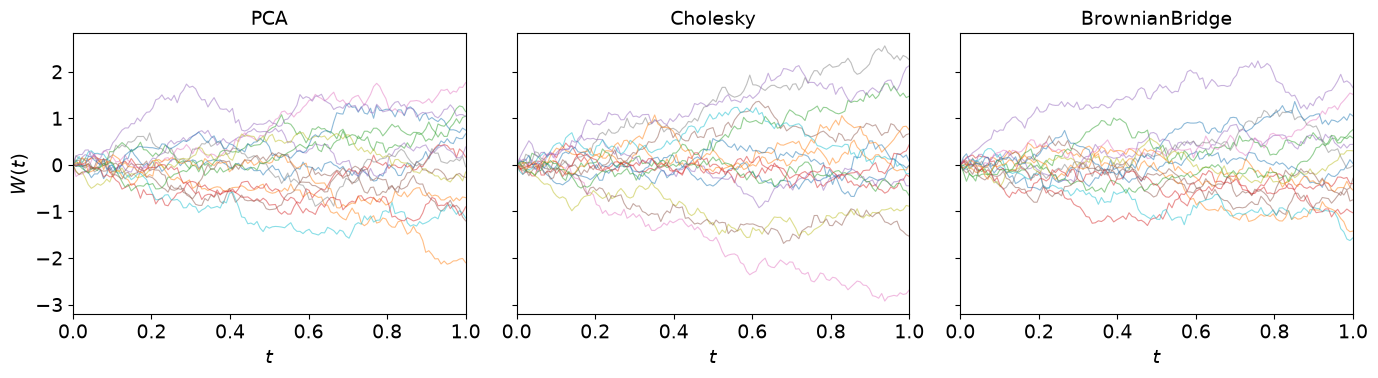

In [15]:
d = 128
n = 16
t_final = 1.0

fig, axes = pyplot.subplots(1, 3, figsize=(14, 4), sharey=True)
for ax, decomp in zip(axes, ['PCA', 'Cholesky', 'BrownianBridge']):
    bm = BrownianMotion(DigitalNetB2(d, seed=7), t_final=t_final, decomp_type=decomp)
    paths = bm.gen_samples(n)
    times = np.concat([[0], bm.time_vec])
    paths_with_origin = np.concat([np.zeros((n, 1)), paths], axis=-1)
    for path in paths_with_origin:
        ax.plot(times, path, alpha=0.5, linewidth=0.8)
    ax.set_title(decomp)
    ax.set_xlabel('$t$')
    ax.set_xlim(0, t_final)

axes[0].set_ylabel('$W(t)$')
pyplot.tight_layout()
pyplot.show()

## Timing

PCA and Cholesky both cost $O(d^3)$ to build their matrix, while the Brownian Bridge never factors the covariance matrix. Its setup of identifying each point's nearest neighbors still costs $O(d^2)$, but each path costs $O(d)$. Therefore, time savings increase as $d$ grows. 

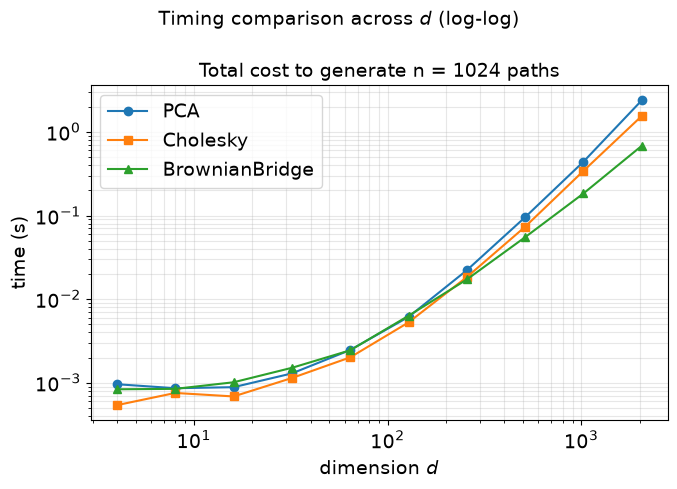

In [23]:
import time, warnings

dims = [4, 8, 16, 32, 64, 128, 256, 512, 1024, 2048]
n = 1024
methods = ['PCA', 'Cholesky', 'BrownianBridge']

total = {m: [] for m in methods}
for d in dims:
    for decomp in methods:
        with warnings.catch_warnings():
            warnings.simplefilter('ignore')
            best = float('inf')
            for _ in range(3):
                start = time.perf_counter()
                bm = BrownianMotion(DigitalNetB2(d, seed=7), decomp_type=decomp)
                bm.gen_samples(n)
                best = min(best, time.perf_counter() - start)
            total[decomp].append(best)

fig, ax = pyplot.subplots(figsize=(7, 5))
for decomp, marker in [('PCA', '-o'), ('Cholesky', '-s'), ('BrownianBridge', '-^')]:
    ax.loglog(dims, total[decomp], marker, label=decomp)
ax.set_title(f'Total cost to generate n = {n} paths')
ax.set_xlabel('dimension $d$')
ax.set_ylabel('time (s)')
ax.grid(True, which='both', alpha=0.3)
ax.legend()
pyplot.suptitle('Timing comparison across $d$ (log-log)')
pyplot.tight_layout()
pyplot.show()

## Custom Monitoring Times

By default, the sampling follows a van der Corput sequence. Custom times can be provided with `monitoring_times` as any set of distinct and positive times and are reordered and sampled in van der Corput order. However, it is possible to pass in `vdc_ordering=False` to sample them in the exact given order. 

In [40]:
bm = BrownianMotion(DigitalNetB2(4, seed=7),
                    decomp_type='BrownianBridge',
                    monitoring_times=[0.6, 1.0, 0.3, 0.8])
bm.time_vec, bm._bridge_times, bm(2) 

(array([0.3, 0.6, 0.8, 1. ]),
 array([1. , 0.6, 0.8, 0.3]),
 array([[-0.02913874,  0.4363325 , -0.07341545,  0.3095377 ],
        [-0.44240726, -1.34558221, -1.22522271, -1.58454187]]))

In [41]:
bm = BrownianMotion(DigitalNetB2(4, seed=7),
                    decomp_type='BrownianBridge',
                    monitoring_times=[0.6, 1.0, 0.3, 0.8], vdc_ordering=False)
bm.time_vec, bm._bridge_times, bm(2) 

(array([0.3, 0.6, 0.8, 1. ]),
 array([0.6, 1. , 0.3, 0.8]),
 array([[-0.42678211,  0.23976687,  0.19961117,  0.56330283],
        [-0.31994843, -1.22738085, -1.29415239, -1.73713917]]))

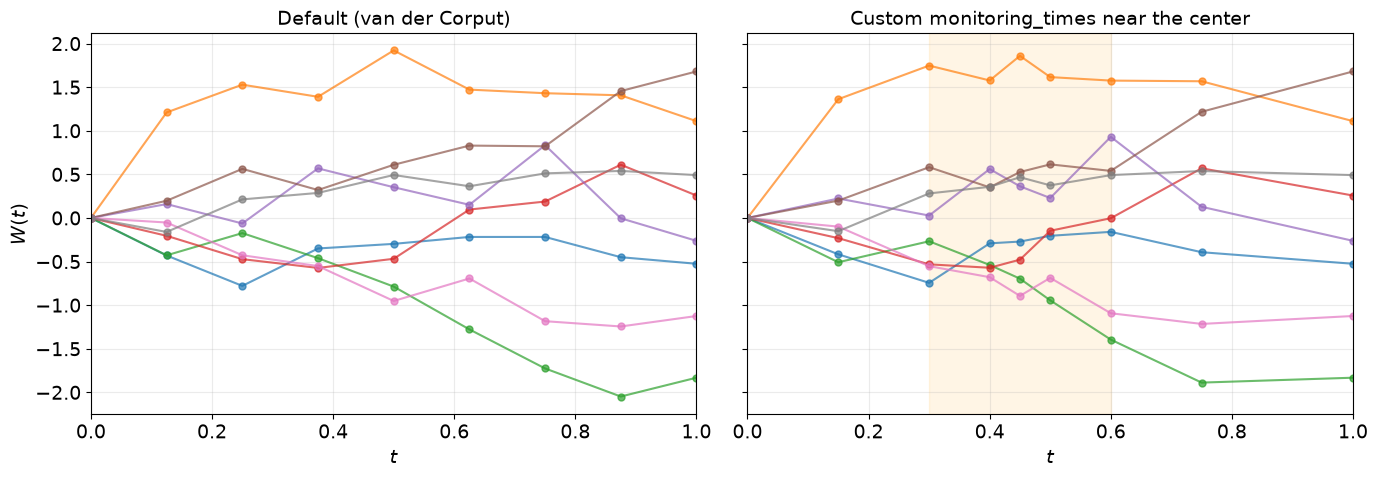

In [30]:
import warnings

d, n = 8, 8
custom = [0.15, 0.3, 0.4, 0.45, 0.5, 0.6, 0.75, 1.0]

with warnings.catch_warnings():
    warnings.simplefilter('ignore')
    bm_default = BrownianMotion(DigitalNetB2(d, seed=7), decomp_type='BrownianBridge')
    bm_custom = BrownianMotion(DigitalNetB2(d, seed=7), decomp_type='BrownianBridge',
                        monitoring_times=custom)

fig, axes = pyplot.subplots(1, 2, figsize=(14, 5), sharey=True)
for ax, bm, title in [(axes[0], bm_default, 'Default (van der Corput)'),
                      (axes[1], bm_custom, 'Custom monitoring_times near the center')]:
    paths = bm.gen_samples(n)
    times = np.concat([[0], bm.time_vec])
    paths_with_origin = np.concat([np.zeros((n, 1)), paths], axis=-1)
    for path in paths_with_origin:
        ax.plot(times, path, '-o', alpha=0.7, ms=5)
    ax.set_title(title)
    ax.set_xlabel('$t$')
    ax.grid(alpha=0.25)
    ax.set_xlim(0, t_final)

axes[1].axvspan(0.3, 0.6, color='orange', alpha=0.1)
axes[0].set_ylabel('$W(t)$')
pyplot.tight_layout()
pyplot.show()

## Option Pricing

An Asian call option priced under each `decomp_type`:

In [20]:
d = 64        # monitoring dates
n = 2**18     # QMC samples
vol = 0.2     # volatility
S0 = 100.0    # initial stock price
K = 100.0     # strike price
r = 0.05      # risk-free rate
t_final = 1.0 # time horizon (years)

In [39]:
print(f"{'decomp_type':<16}  {'price':<20}  {'n':<10}  {'time'}")
print('-' * 80)
methods = ['PCA', 'Cholesky', 'BrownianBridge']

for decomp in methods:
    start = time.perf_counter()
    option = FinancialOption(
        DigitalNetB2(d, seed=7),
        option='ASIAN',
        volatility=vol,
        start_price=S0,
        strike_price=K,
        interest_rate=r,
        t_final=t_final,
        call_put='call',
        asian_mean='arithmetic',
        decomp_type=decomp,
    )
    best = float('inf')
    price, data = CubQMCNetG(option, abs_tol=1e-3).integrate()
    best = min(best, time.perf_counter() - start)
    # print(f"{decomp:<16}  {price:<20}  {data.n_total:<10}  {data.time_integrate}")
    print(f"{decomp:<16}  {price:<20}  {data.n_total:<10}  {best}")

decomp_type       price                 n           time
--------------------------------------------------------------------------------
PCA               5.755328539936192     32768       0.03417829191312194
Cholesky          5.754380457646395     262144      0.10220879083499312
BrownianBridge    5.754664335915994     65536       0.021243999944999814


## References

<a id="ref1"></a>
[1] Owen, A. B. (2013). Monte Carlo theory, methods and examples. https://artowen.su.domains/mc/

<a id="ref2"></a>
[2] Giles, M. B., Kuo, F. Y., Sloan, I. H., and Waterhouse, B. J. (2008). Quasi-Monte Carlo for finance applications. 

<a id="ref3"></a>
[3] Glasserman, P. (2003). Monte Carlo Methods in Financial Engineering. Springer-Verlag, New York.

<a id="ref4"></a>
[4] Herrera, C. and Paulot, L. (2014). Parallel American Monte Carlo. 